In [1]:
import sys
from pathlib import Path

# Find project root (folder containing 'src')
notebook_dir = Path().resolve()
project_root = notebook_dir
for parent in [notebook_dir] + list(notebook_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"src exists: {(project_root / 'src').exists()}")
print(f"loader exists: {(project_root / 'src' / 'data' / 'loader.py').exists()}")

# Now imports will work
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import get_connection, query

con = get_connection()
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
SAVE = '../outputs/figures/'
print("All imports ready!")

Project root: C:\Users\SUN\qcomm-market-basket-analysis
src exists: True
loader exists: True
  orders already loaded
  order_products_prior already loaded
  order_products_train already loaded
  products already loaded
  aisles already loaded
  departments already loaded
All imports ready!


<bound method Axes.set of <Axes: >>

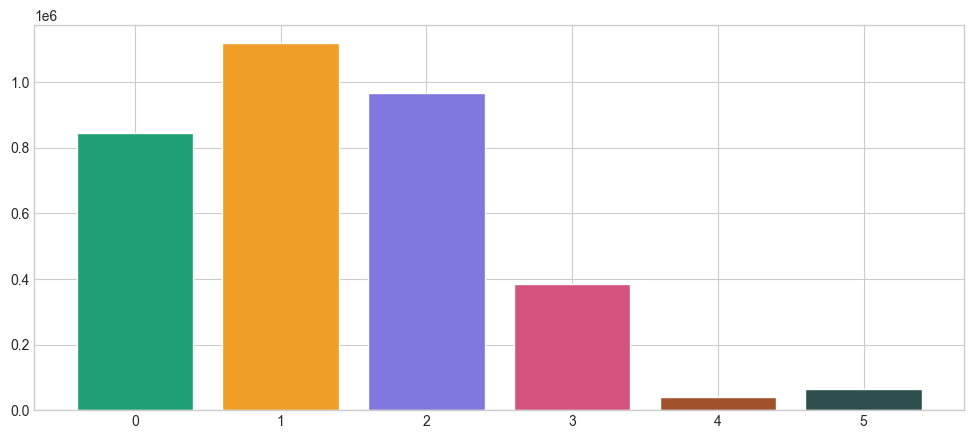

In [5]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

# Define q-comm time slots based on real quick-commerce patterns
time_slots = query("""
    SELECT 
        CAST(order_hour_of_day AS INTEGER) AS order_hour_of_day,
        COUNT(*) AS order_count,
        CASE 
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 0 AND 5   THEN 'Late Night (0-5)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 6 AND 10  THEN 'Morning (6-10)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 11 AND 14 THEN 'Lunch (11-14)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 15 AND 18 THEN 'Afternoon (15-18)'
            WHEN CAST(order_hour_of_day AS INTEGER) BETWEEN 19 AND 22 THEN 'Evening (19-22)'
            ELSE 'Late Evening (23)'
        END AS time_slot
    FROM orders
    GROUP BY order_hour_of_day
    ORDER BY order_hour_of_day
""", con)

# Visualize time slot distribution
slot_counts = time_slots.groupby('time_slot')['order_count'].sum().reindex([
    'Morning (6-10)', 'Lunch (11-14)', 'Afternoon (15-18)', 
    'Evening (19-22)', 'Late Evening (23)', 'Late Night (0-5)'
])

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#1D9E75', '#EF9F27', '#7F77DD', '#D4537E', '#A0522D', '#2F4F4F']
bars = ax.bar(range(len(slot_counts)), slot_counts.values, color=colors, edgecolor='white', linewidth=1)
ax.set_xticks(range(len(slot_counts)))
ax.set

In [ ]:
print(query)
